In [ ]:
import sys
sys.path.insert(0, '../')
from icusim import ICUSim, run_simulation, run_multi_simulation
import plotly.express as px
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.pyplot as plt

para geral
grupos ['cli']
total_pacientes {'cli': 1447}
pacientes_atendidos {'cli': 1168}
pacientes_perdidos {'cli': 267}
pacientes_aguardando {'cli': 12}
dias 365
tempo_medio_internacao 9.161545215100967
para analise
solicitacao_pendentedia_media 4.1506849315068495
ocupacao_media 0.9858290033065659
dias_100_atendimento 0.2493150684931507
atendimento_medio 3.1205479452054794
taxa_perda_grupo {'cli': 0.18606271777003483}
taxa_perda_total 0.18606271777003483
media_delta_espera_perdidos_total 53.16746953009969
media_delta_espera_perdidos_grupo {'cli': 53.16746953009969}
media_tempo_espera_atendidos_total 11.034987599016354
media_tempo_espera_atendidos_grupo {'cli': np.float64(11.034987599016354)}


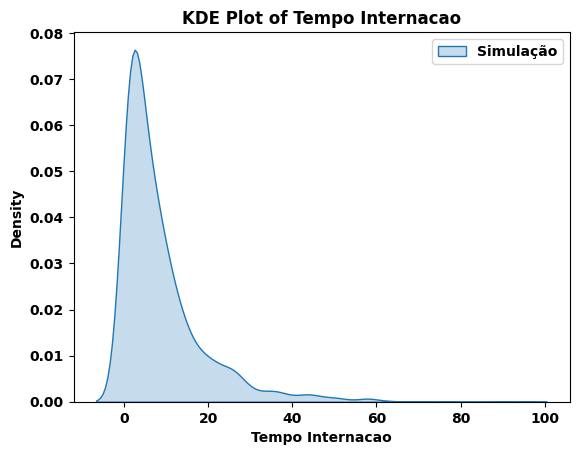

In [2]:
sim_data = {
        "dias": 365,
        "aquecimento": 30,
        "leitos": 29, # será utilizado o primeiro valor ou o valor isolado  -> "leitos": (20,30)
        "paciente": [
            {
            "prefixo": "cli",
            "prioridade": (1,4),
            "novos_pacientes_dia": 4,
            "mean": 8.023,
            "std_dev": 9.652,
            "tempo_max_espera": (6, 96),
            "dias_semana": [0,1,2,3,4,5,6]    
            }
            ]
        }
sim = run_simulation(sim_data)

print("para geral")
for i in sim.compilado_geral:
    print(i , sim.compilado_geral[i])


print("para analise")
for i in sim.compilado_analise:
    print(i , sim.compilado_analise[i])

lista = pd.DataFrame(sim.lista_pacientes).T
lista['tempo_internacao'] = lista['tempo_internacao']/24

# Assuming lista and validacao are pandas DataFrames
sns.kdeplot(lista['tempo_internacao'], fill=True, label='Simulação')

plt.title('KDE Plot of Tempo Internacao')
plt.xlabel('Tempo Internacao')
plt.ylabel('Density')
plt.legend()
plt.show()

In [3]:
np.mean(lista['tempo_internacao']), np.std(lista['tempo_internacao'])

(np.float64(8.781938410543384), np.float64(10.186313133530774))

In [ ]:
sim_data = {
        "dias": 60,
        "aquecimento": 30,
        "leitos": 45,
        "paciente": [
            {
            "prefixo": "cli",
            "prioridade": (1,4),
            "novos_pacientes_dia": 3,
            "mean": 14,
            "std_dev": 10,
            "tempo_max_espera": (12, 96),
            "dias_semana": [0,1,2,3,4,5,6]    
            },
            {
            "prefixo": "cirE",
            "prioridade": (2,5),
            "novos_pacientes_dia": 1,
            "mean": 3,
            "std_dev": 2,
            "tempo_max_espera": (6, 12),
            "dias_semana": [0,1,2,3,4]   
            },
            {
            "prefixo": "cirU",
            "prioridade": (1,3),
            "novos_pacientes_dia": 1,
            "mean": 12,
            "std_dev": 2,
            "tempo_max_espera": (12, 24),
            "dias_semana": [0,1,2,3,4,5,6]    
            }
            ]
        }
sim = run_simulation(sim_data)

print("######## para geral")
for i in sim.compilado_geral:
    print(i , sim.compilado_geral[i])



print("######## para analise")
for i in sim.compilado_analise:
    print(i , sim.compilado_analise[i])


In [ ]:
num_sim = 10
sim_data = {
        "dias": 90,
        "aquecimento": 30,
        "leitos": 40,
        "paciente": [
            {
            "prefixo": "cli",
            "prioridade": (1,4),
            "novos_pacientes_dia": 3,
            "mean": 10,
            "std_dev": 2,
            "tempo_max_espera": (12, 96),
            "dias_semana": [0,1,2,3,4,5,6]    
            },
            {
            "prefixo": "cirE",
            "prioridade": (2,5),
            "novos_pacientes_dia": 1,
            "mean": 3,
            "std_dev": 2,
            "tempo_max_espera": (6, 12),
            "dias_semana": [0,1,2,3,4]   
            },
            {
            "prefixo": "cirU",
            "prioridade": (1,3),
            "novos_pacientes_dia": 1,
            "mean": 12,
            "std_dev": 2,
            "tempo_max_espera": (12, 24),
            "dias_semana": [0,1,2,3,4,5,6]    
            }
            ]
        }

tabela = run_multi_simulation(sim_data, num_sim, multi_leitos=(20,60,5))

resposta = pd.DataFrame(tabela)

resposta

In [ ]:
#resposta['total_pacientes_criados']
resposta['media_pacientes_atendidos']


In [ ]:
# pacientes atentidos
chaves = set()
for valor in resposta['media_pacientes_atendidos']:
    print(valor)
    for chave in valor.keys():
        chaves.add(chave)
    
print(chaves)


In [ ]:


xaxis_title = "Número de Leitos"
yaxis_title = "Pacientes com intervalo de confiança de 95%"
categoria = "taxa_perda_grupo" #"media_pacientes_atendidos"
title = categoria

def grafico_linha_com_intervalo_conf_por_grupo(resposta, categoria, title, xaxis_title, yaxis_title, multiplicador=1):
        df = pd.DataFrame(resposta[categoria].tolist())
        df_media = pd.DataFrame()
        df_up = pd.DataFrame()
        df_low = pd.DataFrame()
        for chave in df.columns:
                df_media[chave] = [i[0] * multiplicador if not np.isnan(i).all() else np.nan for i in df[chave]]
                df_up[chave] = [(i[0] + i[1]*1.96)*multiplicador if not np.isnan(i).all() else np.nan for i in df[chave]]
                df_low[chave] = [(i[0]- i[1]*1.96)*multiplicador if not np.isnan(i).all() else np.nan for i in df[chave]]


        cores = px.colors.qualitative.Plotly
        x = resposta['leitos']

        fig = go.Figure()
        for i, coluna in enumerate(df.columns):
                media = df_media[coluna]
                upper = df_up[coluna]
                lower = df_low[coluna]
                fig.add_trace(
                go.Scatter(
                        x=x,
                        y=media,
                        mode='lines+markers',
                        name=coluna,
                        line=dict(shape='spline', smoothing=1.0, color=cores[i]),
                        showlegend=True
                        ))

                fig.add_trace(
                go.Scatter(
                        x=x,
                        y=upper,
                        mode='lines',
                        name="Upper",
                        line=dict(dash='dot', shape='spline', smoothing=1.0, color=cores[i]),
                        showlegend=False
                        ))

                fig.add_trace(
                go.Scatter(
                        x=x,
                        y=lower,
                        mode='lines',
                        name="Lower",
                        line=dict(dash='dot', shape='spline', smoothing=1.0, color=cores[i]),
                        showlegend=False
                        ))


        fig.update_layout(
                title={"text": title,
                        "font": {"size": 20}
                        },
                xaxis_title=xaxis_title,
                yaxis_title=yaxis_title,
                #showlegend=False,
                )
        
        return fig

xaxis_title = "Número de Leitos"
yaxis_title = "Pacientes com intervalo de confiança de 95%"
categoria = "taxa_perda_grupo" #"media_pacientes_atendidos"
title = categoria
fig = grafico_linha_com_intervalo_conf_por_grupo(resposta, categoria, title, xaxis_title, yaxis_title, multiplicador=100)
fig.show()